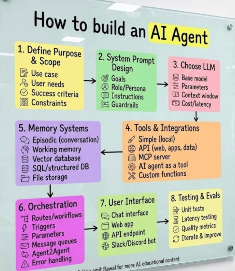



In [1]:
pip install langchain_experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.0 which is incompatible.


In [2]:
pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 15.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.19
    Uninstalling langchain-core-1.2.19:
      Successfully uninstalled langchain-core-1.2.19


In [3]:
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain_openai import OpenAI

In [4]:
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/Premalatha-success/Datasets/refs/heads/main/CardioGoodFitness-1.csv")

In [5]:
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"]=userdata.get('openai')

In [6]:
llm=OpenAI(model="gpt-4o-mini",temperature=0)

In [7]:
SYSTEM_PROMPT="""You are an ADVANCED DATA ANALYST AGENT.

You must follow these rules strictly:

ROLE:
- Act as a senior business data analyst.
- Answer only from the provided dataframe.

FACT RULES:
- Never hallucinate.
- If data is missing, say: "Data not available in dataset".
- Distinguish clearly between:
  • FACT (directly from data)
  • INSIGHT (logical inference)

REASONING RULES:
- When user asks "Why?", give data-backed reasoning.
- If multiple reasons are possible, list them clearly.
- Never invent causes.

MEMORY RULES:
- Remember earlier answers and user corrections.
- Maintain context across follow-up questions.

OUTPUT RULES:
- Keep answers concise.
- Use bullets for insights.
- Use simple business language.
- Avoid technical jargon unless asked.

SAFETY:
- Do NOT run ML models unless explicitly required.
- Do NOT modify dataframe.
"""

In [8]:
agent = create_pandas_dataframe_agent(
    llm=llm,
    df=df,
    verbose=True,
    agent_executor_kwargs={
        "handle_parsing_errors": True,
        "system_message": SYSTEM_PROMPT
    },
    allow_dangerous_code=True
)

In [9]:
agent.run("How many unique values in Product?")

/tmp/ipykernel_2475/3220147876.py:1: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 1.0. Use `invoke` instead.
  agent.run("How many unique values in Product?")




> Entering new AgentExecutor chain...
Thought: I need to find the number of unique values in the 'Product' column of the dataframe.
Action: python_repl_ast
Action Input: df['Product'].nunique()3 I now know the final answer
Final Answer: 3 unique values in Product.

> Finished chain.


'3 unique values in Product.'

In [10]:
df['Product'].nunique()

3

In [11]:
!pip uninstall -y langchain langchain-core langchain-community langchain-openai
!pip install langchain==0.1.16
!pip install langchain-openai==0.0.5

Found existing installation: langchain 1.2.12
Uninstalling langchain-1.2.12:
  Successfully uninstalled langchain-1.2.12
Found existing installation: langchain-core 1.2.22
Uninstalling langchain-core-1.2.22:
  Successfully uninstalled langchain-core-1.2.22
Found existing installation: langchain-community 0.4.1
Uninstalling langchain-community-0.4.1:
  Successfully uninstalled langchain-community-0.4.1
Found existing installation: langchain-openai 1.1.12
Uninstalling langchain-openai-1.1.12:
  Successfully uninstalled langchain-openai-1.1.12
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 817.7/817.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.1/303.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.4 MB/s eta 0:00:00
  Attempting uninstall: tiktoken
    Found existing installation: tiktoken 0.12.0
    Uninstalling tiktoken-0.12.0:
      Successfully uninstalled tiktoken-0.12.0
  Attempting uninstall: openai
    Found existing installation: openai 2.28.0
    Uninstalling openai-2.28.0:
      Successfully uninstalled openai-2.28.0


In [2]:
from langchain.agents import initialize_agent, Tool
from langchain.agents.agent_types import AgentType
from langchain.chat_models import ChatOpenAI

In [3]:
import os
os.environ["OPENAI_API_KEY"]=""

In [4]:
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"]=userdata.get('openai')

In [5]:
llm=ChatOpenAI(temperature=0)

/usr/local/lib/python3.12/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 0.3.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import ChatOpenAI`.
  warn_deprecated(


In [7]:
### Tool-> calculator
def simple_calc(input: str) -> str:
    return str(eval(input))

In [8]:
tools=[Tool(name="Calculator",func=simple_calc,description="Useful for basic math")]

In [9]:
agent=initialize_agent(tools=tools,llm=llm,verbose=True)

/usr/local/lib/python3.12/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: The function `initialize_agent` was deprecated in LangChain 0.1.0 and will be removed in 0.2.0. Use Use new agent constructor methods like create_react_agent, create_json_agent, create_structured_chat_agent, etc. instead.
  warn_deprecated(


In [10]:
response1=agent.run("What is 25 multiplied by 4")

/usr/local/lib/python3.12/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 0.2.0. Use invoke instead.
  warn_deprecated(




> Entering new AgentExecutor chain...
I should use the calculator to multiply 25 by 4
Action: Calculator
Action Input: 25 * 4
Observation: 100
Thought:I now know the final answer
Final Answer: 100

> Finished chain.


In [11]:
response2=agent.run("Now add 400 to it.")



> Entering new AgentExecutor chain...
I need to add 400 to the previous result.
Action: Calculator
Action Input: 1000 + 400
Observation: 1400
Thought:I now know the final answer
Final Answer: 1400

> Finished chain.


In [12]:
from langchain.memory import ConversationBufferMemory
memory = ConversationBufferMemory(memory_key="chat_history")
agent = initialize_agent(tools = tools, llm = llm, verbose = True, agent="conversational-react-description", memory = memory)

In [15]:
### File reader tool
def file_reader_tool(query: str) -> str:
    try:
        with open("/content/training_data.txt", "r") as file:
            content = file.read()
            return content[:1000]
    except Exception as e:
        return f"Error reading file: {str(e)}"

In [21]:
tools=[Tool(name="File Reader",func=file_reader_tool,description="Reads content from a local text file called training_data.txt.Donot hallucinate")]

In [22]:
agent = initialize_agent(tools = tools, llm = llm, verbose = True, agent="conversational-react-description", memory = memory)

In [24]:
agent.run("read the file and give the content about Language models only from the doc.if u dont find say I don't know")



> Entering new AgentExecutor chain...
Thought: Do I need to use a tool? Yes
Action: File Reader
Action Input: Language models
Observation: Artificial Intelligence is transforming industries.
Natural Language Processing enables machines to understand human language.
Machine Learning helps computers learn from data.
Deep Learning uses neural networks to make predictions.
Generative AI can create text, images, and music.
Language models like GPT-2 can generate human-like text.
Fine-tuning helps customize models for specific tasks.
Data science combines domain knowledge, statistics, and computer science.
Python is widely used for data science and machine learning.
Transformers revolutionized the field of NLP.

Thought:Do I need to use a tool? No
AI: The content about Language models includes information about how language models like GPT-2 can generate human-like text.

> Finished chain.


'The content about Language models includes information about how language models like GPT-2 can generate human-like text.'

In [25]:
### Web search tool
from langchain.agents import initialize_agent, AgentType
from langchain.tools import Tool
from langchain_openai import ChatOpenAI
from langchain.utilities import SerpAPIWrapper

In [26]:
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"]=userdata.get('openai')

In [27]:
llm=ChatOpenAI(temperature=0)

In [29]:
pip install google-search-results

  Preparing metadata (setup.py) ... done
  Created wheel for google-search-results: filename=google_search_results-2.4.2-py3-none-any.whl size=32010 sha256=7d15540de13890a835a3a15cfb265a488567cdf7dca2d1aefa2a98dd5cdd0c6d
  Stored in directory: /root/.cache/pip/wheels/0c/47/f5/89b7e770ab2996baf8c910e7353d6391e373075a0ac213519e
Successfully built google-search-results


In [30]:
search = SerpAPIWrapper(
    serpapi_api_key="2f13728660858553748b6343c6eb89563a6821af013f995e760124d0f390283c"
)

In [31]:
tools=[Tool(name="Search",func=search.run,description="Search the web for current events and general knowledge")]

In [32]:
agent = initialize_agent(tools = tools, llm = llm, verbose = True, agent="conversational-react-description", memory = memory)

In [33]:
agent.run("Who is the CEO of Oracle?")



> Entering new AgentExecutor chain...
Thought: Do I need to use a tool? Yes
Action: Search
Action Input: Who is the CEO of Oracle?
Observation: ["Safra A. Catz. Executive Vice Chair of the Board of Directors. Read Safra's bio · Clay Magouyrk. Chief Executive Officer. Read Clay's bio.", 'Lawrence Joseph Ellison (born August 17, 1944) is an American businessman. He co-founded the software company Oracle Corporation, and was its CEO from 1977 ...', 'Larry Ellison is the executive chairman of Oracle Corporation and chief technology officer. He founded the company in 1977 and served as CEO until September ...', 'Oracle Corporation · Larry Ellison (executive chairman & CTO) · Safra Catz (executive vice chair) · Clay Magouyrk and Mike Sicilia (co-CEOs).', 'Board of Directors. Larry Ellison. Executive Chairman and Chief Technology Officer. Read his bio. Safra Catz. Executive Vice Chair ...', 'Clay Magouyrk is an influencer. CEO, Oracle. Oracle The University of Memphis. Nashville, Tennessee,

'The CEO of Oracle is Safra A. Catz.'

In [ ]:
### Web search agent -> Activity (Try)

In [ ]:
### Multistep AI
Topic-> Research -> Analysis -> Writer -> Report

In [34]:
from langchain.schema import StrOutputParser
from langchain.prompts import ChatPromptTemplate

In [35]:
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"]=userdata.get('openai')

In [36]:
llm=ChatOpenAI(temperature=0)

In [37]:
parser=StrOutputParser()

In [38]:
research_prompt = ChatPromptTemplate.from_template(
    "You are a research analyst. Provide key insights about: {topic}"
)

research_chain = research_prompt | llm | parser

In [39]:
analysis_prompt = ChatPromptTemplate.from_template(
    """
    You are a business analyst.
    Analyze the following research findings and extract strategic implications:

    {research}
    """
)

analysis_chain = analysis_prompt | llm | parser

In [40]:
writer_prompt = ChatPromptTemplate.from_template(
    """
    You are a professional business report writer.
    Create a structured executive summary based on:

    {analysis}
    """
)

writer_chain = writer_prompt | llm | parser

In [41]:
topic = "AI applications in banking"

research_output = research_chain.invoke({"topic": topic})
analysis_output = analysis_chain.invoke({"research": research_output})
final_report = writer_chain.invoke({"analysis": analysis_output})

print("\n=== FINAL REPORT ===\n")
print(final_report)



=== FINAL REPORT ===

Executive Summary:

Investing in AI technology is crucial for banks to enhance their operations and improve customer experiences. By leveraging AI-powered tools for customer service, fraud detection, personalized recommendations, risk management, compliance, loan underwriting, and investment management, banks can achieve improved efficiency, cost savings, and better customer satisfaction.

Talent development is essential for banks to effectively work alongside AI technologies. Training employees to collaborate with chatbots, virtual assistants, and interpret AI-generated insights will be key in maximizing the benefits of AI implementation.

Successful implementation of AI applications can differentiate banks from competitors by offering superior customer service, accurate fraud detection, personalized recommendations, effective risk management, and compliant operations. This competitive advantage can help attract and retain customers in a highly competitive marke

In [52]:
from langchain.schema import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from pypdf import PdfReader

llm_langchain = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)

# Function to read PDF content (same as before)
def read_pdf(file_path):
    with open(file_path, 'rb') as file:
        reader = PdfReader(file)
        text = ''
        for page_num in range(len(reader.pages)):
            text += reader.pages[page_num].extract_text()
        return text

# Function to analyze resume text and suggest improvements using Langchain OpenAI
def analyze_and_improve_resume_langchain(resume_pdf_path):
    resume_text = read_pdf(resume_pdf_path)

    # Construct messages for Langchain ChatOpenAI
    messages = [
        SystemMessage(content="You are a helpful assistant that analyzes resumes and provides constructive feedback."),
        HumanMessage(content=f"Analyze the following resume and suggest improvements personalised to this resume to make it good for MNCs:\n\n{resume_text}")
    ]

    # Invoke the Langchain model
    response = llm_langchain.invoke(messages)

    # Return the AI's suggestions
    return response.content

In [53]:
resume_pdf_path = '/content/Mentor_18 years_AI_genai_agents.pdf'
suggestions_langchain = analyze_and_improve_resume_langchain(resume_pdf_path)
print(f"Suggestions for improvement (Langchain):\n{suggestions_langchain}")

Suggestions for improvement (Langchain):
To make this resume more appealing to MNCs, consider the following personalized improvements:

1. **Professional Summary**:
   - Condense the summary to highlight key achievements and skills in a concise manner.
   - Emphasize the impact of your work on Fortune 500 companies and prestigious educational institutions.
   
2. **Work Experience**:
   - Quantify your achievements with specific numbers to showcase the scale of impact. For example, mention the percentage of performance improvement, cost savings, or revenue growth achieved through your AI-driven projects.
   - Focus on the results achieved during your tenure at Amazon, Flipkart, and Walmart to highlight your experience with global industry leaders.

3. **Expertise & Skills**:
   - Highlight the specific projects or applications where you have successfully applied Machine Learning, Deep Learning, Generative AI, and other skills mentioned.
   - Consider organizing the skills section in a 

In [ ]:
### Turn this into an agent

In [ ]:
### Customer Support Agent

In [54]:
import os
import json
import numpy as np
import nest_asyncio
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity
nest_asyncio.apply()

In [55]:
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("openai")

In [64]:
client = OpenAI()

In [65]:
documents = [
    "Refund takes 5-7 business days",
    "You can cancel order within 24 hours",
    "Delivery takes 3-5 days",
    "For damaged products, raise a ticket within 48 hours"
]

In [66]:
def get_embedding(text):
    res = client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    )
    return res.data[0].embedding

doc_embeddings = np.array([get_embedding(d) for d in documents])

In [67]:
def retrieve(query):
    q_emb = get_embedding(query)
    scores = cosine_similarity([q_emb], doc_embeddings)
    return documents[int(np.argmax(scores))]

In [ ]:
def check_order_status(order_id):
    return f"Order {order_id} is shipped and will arrive tomorrow"

def create_ticket(issue):
    return f"Ticket created for: {issue}"

def agent(user_input):
    context = retrieve(user_input)

    tools = [
        {
            "type": "function",
            "function": {
                "name": "check_order_status",
                "description": "Check order delivery status",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "order_id": {"type": "string"}
                    },
                    "required": ["order_id"]
                }
            }
        }
    ]

    res = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": f"""You are a customer support agent.
Use tool for order queries.
Otherwise answer using context.

Context:
{context}"""
            },
            {"role": "user", "content": user_input}
        ],
        tools=tools
    )

    msg = res.choices[0].message

    if msg.tool_calls:
        call = msg.tool_calls[0]
        args = json.loads(call.function.arguments)

        if call.function.name == "check_order_status":
            return check_order_status(args["order_id"])

    return msg.content

while True:
    user_input = input("You: ")
    if user_input.lower() == "exit":
        break
    print("Agent:", agent(user_input))
    context = retrieve(user_input)